In [1]:
import subprocess
subprocess.run(["pip", "install", "yfinance", "pandas", "numpy", "matplotlib", "scipy"])

CompletedProcess(args=['pip', 'install', 'yfinance', 'pandas', 'numpy', 'matplotlib', 'scipy'], returncode=0)

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Download stock data for 3 stocks to start
tickers = ["HDFCBANK.NS", "TCS.NS", "RELIANCE.NS"]

data = yf.download(tickers, start="2020-01-01", end="2024-12-31")

# Keep only closing prices
close_prices = data["Close"]

print(close_prices.head())
print("\nShape:", close_prices.shape)

[*********************100%***********************]  3 of 3 completed

Ticker      HDFCBANK.NS  RELIANCE.NS       TCS.NS
Date                                             
2020-01-01   605.529358   672.216125  1841.149170
2020-01-02   609.389160   683.660217  1832.697998
2020-01-03   600.698853   684.484070  1869.222046
2020-01-06   587.698792   668.609375  1869.051880
2020-01-07   597.004822   678.895630  1873.639404

Shape: (1237, 3)


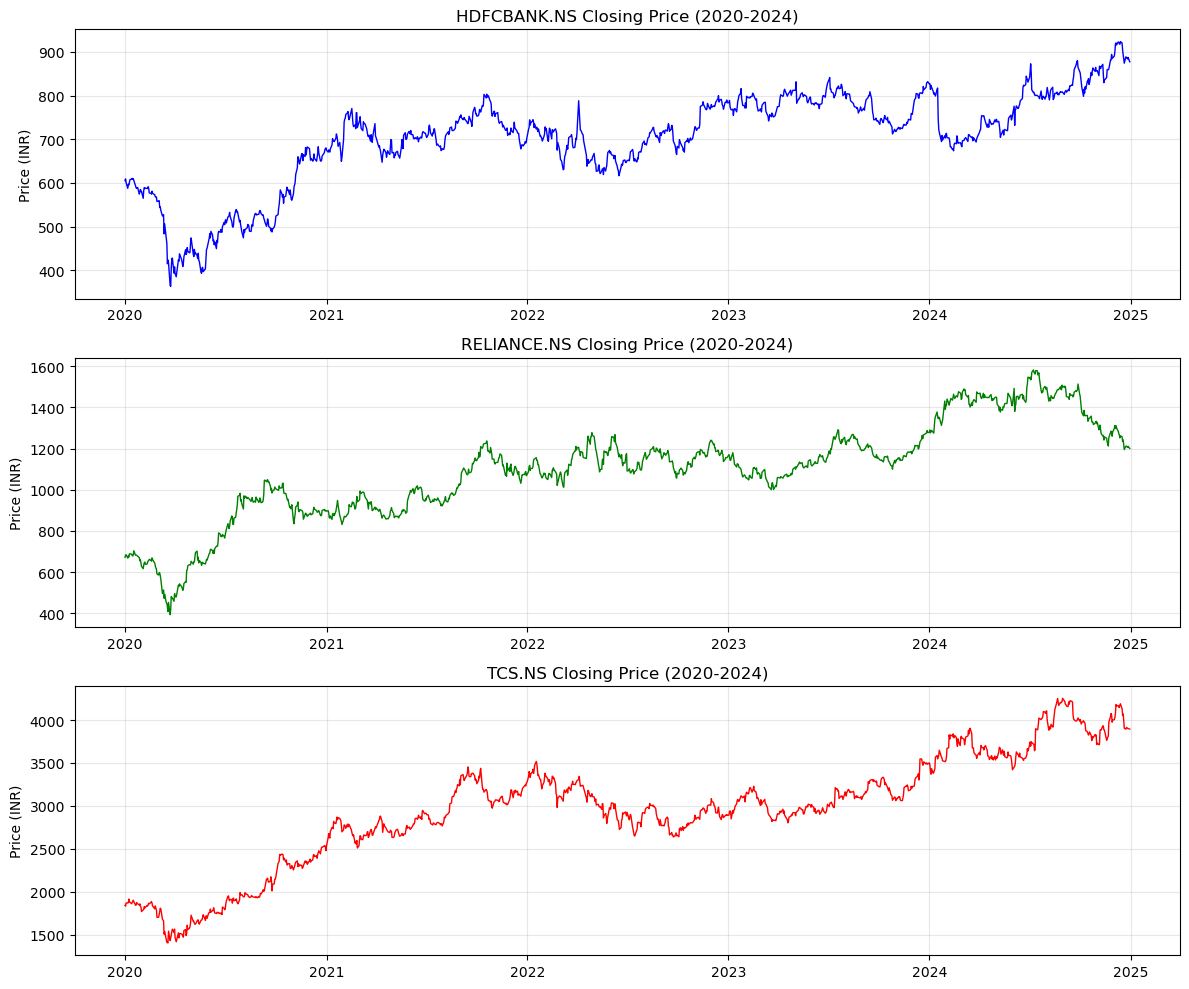

In [4]:
# Plot closing prices for all 3 stocks
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

stocks = ["HDFCBANK.NS", "RELIANCE.NS", "TCS.NS"]
colors = ["blue", "green", "red"]

for i, (stock, color) in enumerate(zip(stocks, colors)):
    axes[i].plot(close_prices.index, close_prices[stock], color=color, linewidth=1)
    axes[i].set_title(f"{stock} Closing Price (2020-2024)")
    axes[i].set_ylabel("Price (INR)")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Calculate daily percentage returns
daily_returns = close_prices.pct_change()

# Drop the first row (it's NaN because there's no previous day to compare)
daily_returns = daily_returns.dropna()

print(daily_returns.head())
print("\nShape:", daily_returns.shape)

Ticker      HDFCBANK.NS  RELIANCE.NS    TCS.NS
Date                                          
2020-01-02     0.006374     0.017024 -0.004590
2020-01-03    -0.014261     0.001205  0.019929
2020-01-06    -0.021642    -0.023192 -0.000091
2020-01-07     0.015835     0.015385  0.002454
2020-01-08    -0.002618    -0.007510  0.022395

Shape: (1236, 3)


In [6]:
# Calculate 30-day rolling realized volatility
# Std dev of daily returns x sqrt(252) to annualize it
realized_vol = daily_returns.rolling(window=30).std() * np.sqrt(252)

# Drop NaN rows (first 30 rows won't have enough data to calculate)
realized_vol = realized_vol.dropna()

print(realized_vol.head())
print("\nAverage Realized Volatility per stock:")
print(realized_vol.mean())

Ticker      HDFCBANK.NS  RELIANCE.NS    TCS.NS
Date                                          
2020-02-12     0.196987     0.253596  0.192477
2020-02-13     0.196405     0.248199  0.193868
2020-02-14     0.198689     0.249930  0.185358
2020-02-17     0.189073     0.241531  0.187117
2020-02-18     0.182656     0.237567  0.187687

Average Realized Volatility per stock:
Ticker
HDFCBANK.NS    0.246364
RELIANCE.NS    0.264477
TCS.NS         0.228980
dtype: float64


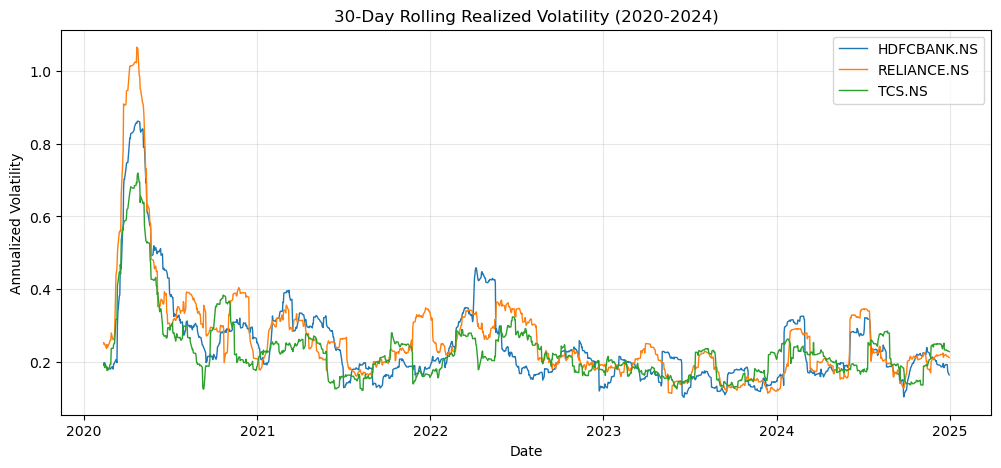

In [7]:
# Plot realized volatility over time for all 3 stocks
plt.figure(figsize=(12, 5))

for stock in ["HDFCBANK.NS", "RELIANCE.NS", "TCS.NS"]:
    plt.plot(realized_vol.index, realized_vol[stock], linewidth=1, label=stock)

plt.title("30-Day Rolling Realized Volatility (2020-2024)")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# All 15 Nifty 50 stocks across 5 sectors
all_tickers = [
    "HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS",      # Banking
    "TCS.NS", "INFY.NS", "WIPRO.NS",                    # IT
    "RELIANCE.NS", "ONGC.NS", "POWERGRID.NS",           # Energy
    "HINDUNILVR.NS", "NESTLEIND.NS", "BRITANNIA.NS",    # FMCG
    "MARUTI.NS", "EICHERMOT.NS", "BAJAJ-AUTO.NS"       # Auto
]

# Download all 15 stocks
all_data = yf.download(all_tickers, start="2020-01-01", end="2024-12-31")
all_close = all_data["Close"]

# Calculate daily returns and realized volatility
all_returns = all_close.pct_change().dropna()
all_rv = all_returns.rolling(window=30).std() * np.sqrt(252)
all_rv = all_rv.dropna()

print("Average Realized Volatility by stock (2020-2024):")
print(all_rv.mean().sort_values(ascending=False))

[*********************100%***********************]  15 of 15 completed


Average Realized Volatility by stock (2020-2024):
Ticker
ONGC.NS          0.347644
EICHERMOT.NS     0.292975
POWERGRID.NS     0.277930
WIPRO.NS         0.275600
ICICIBANK.NS     0.273022
MARUTI.NS        0.264815
RELIANCE.NS      0.264477
KOTAKBANK.NS     0.264437
INFY.NS          0.257430
BAJAJ-AUTO.NS    0.256790
HDFCBANK.NS      0.246364
TCS.NS           0.228980
HINDUNILVR.NS    0.217617
BRITANNIA.NS     0.217542
NESTLEIND.NS     0.206833
dtype: float64


In [9]:
# Define sectors
sectors = {
    "Banking": ["HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS"],
    "IT": ["TCS.NS", "INFY.NS", "WIPRO.NS"],
    "Energy": ["RELIANCE.NS", "ONGC.NS", "POWERGRID.NS"],
    "FMCG": ["HINDUNILVR.NS", "NESTLEIND.NS", "BRITANNIA.NS"],
    "Auto": ["MARUTI.NS", "EICHERMOT.NS", "BAJAJ-AUTO.NS"]
}

# Calculate average volatility per sector
print("Average Realized Volatility by Sector (2020-2024):")
print("-" * 40)
for sector, stocks in sectors.items():
    sector_vol = all_rv[stocks].mean(axis=1).mean()
    print(f"{sector:10} : {sector_vol:.1%}")

Average Realized Volatility by Sector (2020-2024):
----------------------------------------
Banking    : 26.1%
IT         : 25.4%
Energy     : 29.7%
FMCG       : 21.4%
Auto       : 27.2%


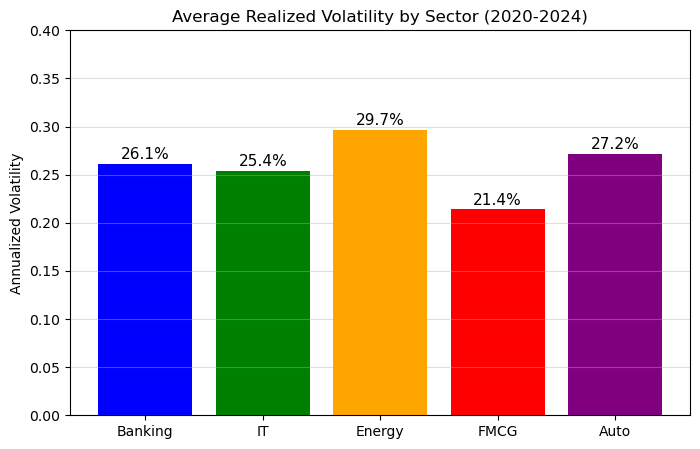

In [10]:
# Bar chart of sector volatility
sector_names = []
sector_vols = []

for sector, stocks in sectors.items():
    sector_vol = all_rv[stocks].mean(axis=1).mean()
    sector_names.append(sector)
    sector_vols.append(sector_vol)

plt.figure(figsize=(8, 5))
bars = plt.bar(sector_names, sector_vols, color=["blue", "green", "orange", "red", "purple"])
plt.title("Average Realized Volatility by Sector (2020-2024)")
plt.ylabel("Annualized Volatility")
plt.ylim(0, 0.40)

# Add percentage labels on top of each bar
for bar, vol in zip(bars, sector_vols):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{vol:.1%}", ha="center", fontsize=11)

plt.grid(True, alpha=0.4, axis="y")
plt.show() 

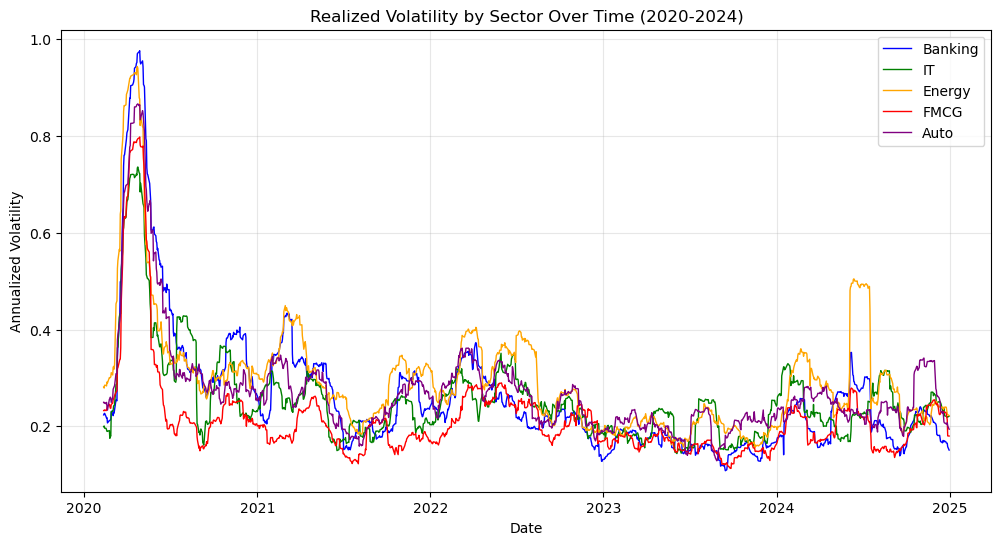

In [11]:
# Plot realized volatility over time by sector
plt.figure(figsize=(12, 6))

colors = {"Banking": "blue", "IT": "green", "Energy": "orange", "FMCG": "red", "Auto": "purple"}

for sector, stocks in sectors.items():
    sector_rv = all_rv[stocks].mean(axis=1)
    plt.plot(sector_rv.index, sector_rv, linewidth=1, label=sector, color=colors[sector])

plt.title("Realized Volatility by Sector Over Time (2020-2024)")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Download India VIX data
vix_data = yf.download("^INDIAVIX", start="2020-01-01", end="2024-12-31")

# Keep only closing price
vix_close = vix_data["Close"]

# VIX is quoted as a percentage (e.g. 20 means 20%)
# Convert to decimal to match our realized vol format
vix_decimal = vix_close / 100

print(vix_decimal.head())
print(f"\nAverage India VIX (2020-2024): {vix_decimal.mean().values[0]:.1%}")

[*********************100%***********************]  1 of 1 completed

Ticker      ^INDIAVIX
Date                 
2020-01-02     0.1149
2020-01-03     0.1270
2020-01-06     0.1478
2020-01-07     0.1461
2020-01-08     0.1564

Average India VIX (2020-2024): 18.3%


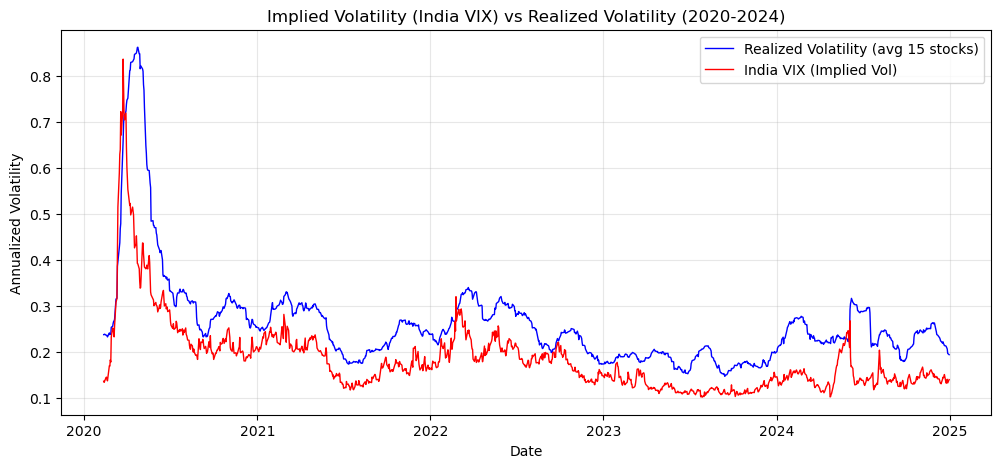

In [13]:
# Calculate average realized volatility across all 15 stocks each day
avg_rv = all_rv.mean(axis=1)

# Align VIX and RV to same dates
common_dates = avg_rv.index.intersection(vix_decimal.index)
avg_rv_aligned = avg_rv[common_dates]
vix_aligned = vix_decimal.loc[common_dates]

# Plot both on same chart
plt.figure(figsize=(12, 5))
plt.plot(avg_rv_aligned.index, avg_rv_aligned, color="blue", linewidth=1, label="Realized Volatility (avg 15 stocks)")
plt.plot(vix_aligned.index, vix_aligned, color="red", linewidth=1, label="India VIX (Implied Vol)")
plt.title("Implied Volatility (India VIX) vs Realized Volatility (2020-2024)")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Calculate the Volatility Risk Premium (VRP = RV - VIX)
vrp = avg_rv_aligned - vix_aligned.squeeze()

print(f"Average VRP (2020-2024): {vrp.mean():.1%}")
print(f"% of days where RV > VIX: {(vrp > 0).mean():.1%}")
print(f"\nVRP by year:")
for year in [2020, 2021, 2022, 2023, 2024]:
    year_vrp = vrp[vrp.index.year == year].mean()
    print(f"{year}: {year_vrp:.1%}")

Average VRP (2020-2024): 7.6%
% of days where RV > VIX: 98.5%

VRP by year:
2020: 10.3%
2021: 6.6%
2022: 6.4%
2023: 5.6%
2024: 9.3%


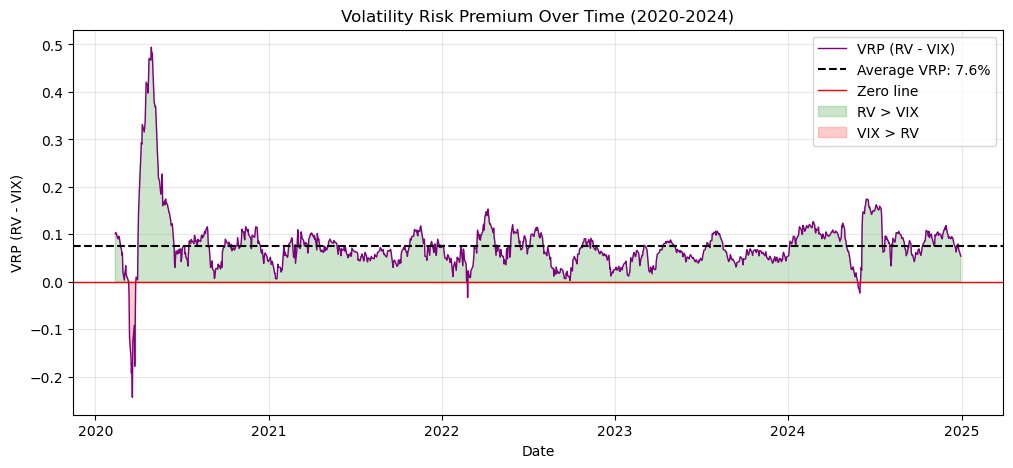

In [15]:
# Plot VRP over time
plt.figure(figsize=(12, 5))
plt.plot(vrp.index, vrp, color="purple", linewidth=1, label="VRP (RV - VIX)")
plt.axhline(y=vrp.mean(), color="black", linewidth=1.5, linestyle="--", label=f"Average VRP: {vrp.mean():.1%}")
plt.axhline(y=0, color="red", linewidth=1, linestyle="-", label="Zero line")
plt.fill_between(vrp.index, vrp, 0, where=(vrp > 0), alpha=0.2, color="green", label="RV > VIX")
plt.fill_between(vrp.index, vrp, 0, where=(vrp < 0), alpha=0.2, color="red", label="VIX > RV")
plt.title("Volatility Risk Premium Over Time (2020-2024)")
plt.ylabel("VRP (RV - VIX)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# Calculate VRP for each sector
print("VRP by Sector (2020-2024):")
print("-" * 40)

for sector, stocks in sectors.items():
    # Average RV for this sector each day
    sector_rv = all_rv[stocks].mean(axis=1)
    
    # Align with VIX dates
    common = sector_rv.index.intersection(vix_decimal.index)
    sector_rv_aligned = sector_rv[common]
    vix_sector = vix_decimal.loc[common].squeeze()
    
    # VRP = RV - VIX
    sector_vrp = sector_rv_aligned - vix_sector
    
    print(f"{sector:10} | Avg VRP: {sector_vrp.mean():.1%} | RV > VIX: {(sector_vrp > 0).mean():.1%} of days")

VRP by Sector (2020-2024):
----------------------------------------
Banking    | Avg VRP: 7.7% | RV > VIX: 95.7% of days
IT         | Avg VRP: 7.0% | RV > VIX: 94.6% of days
Energy     | Avg VRP: 11.3% | RV > VIX: 99.2% of days
FMCG       | Avg VRP: 3.0% | RV > VIX: 76.4% of days
Auto       | Avg VRP: 8.8% | RV > VIX: 98.3% of days


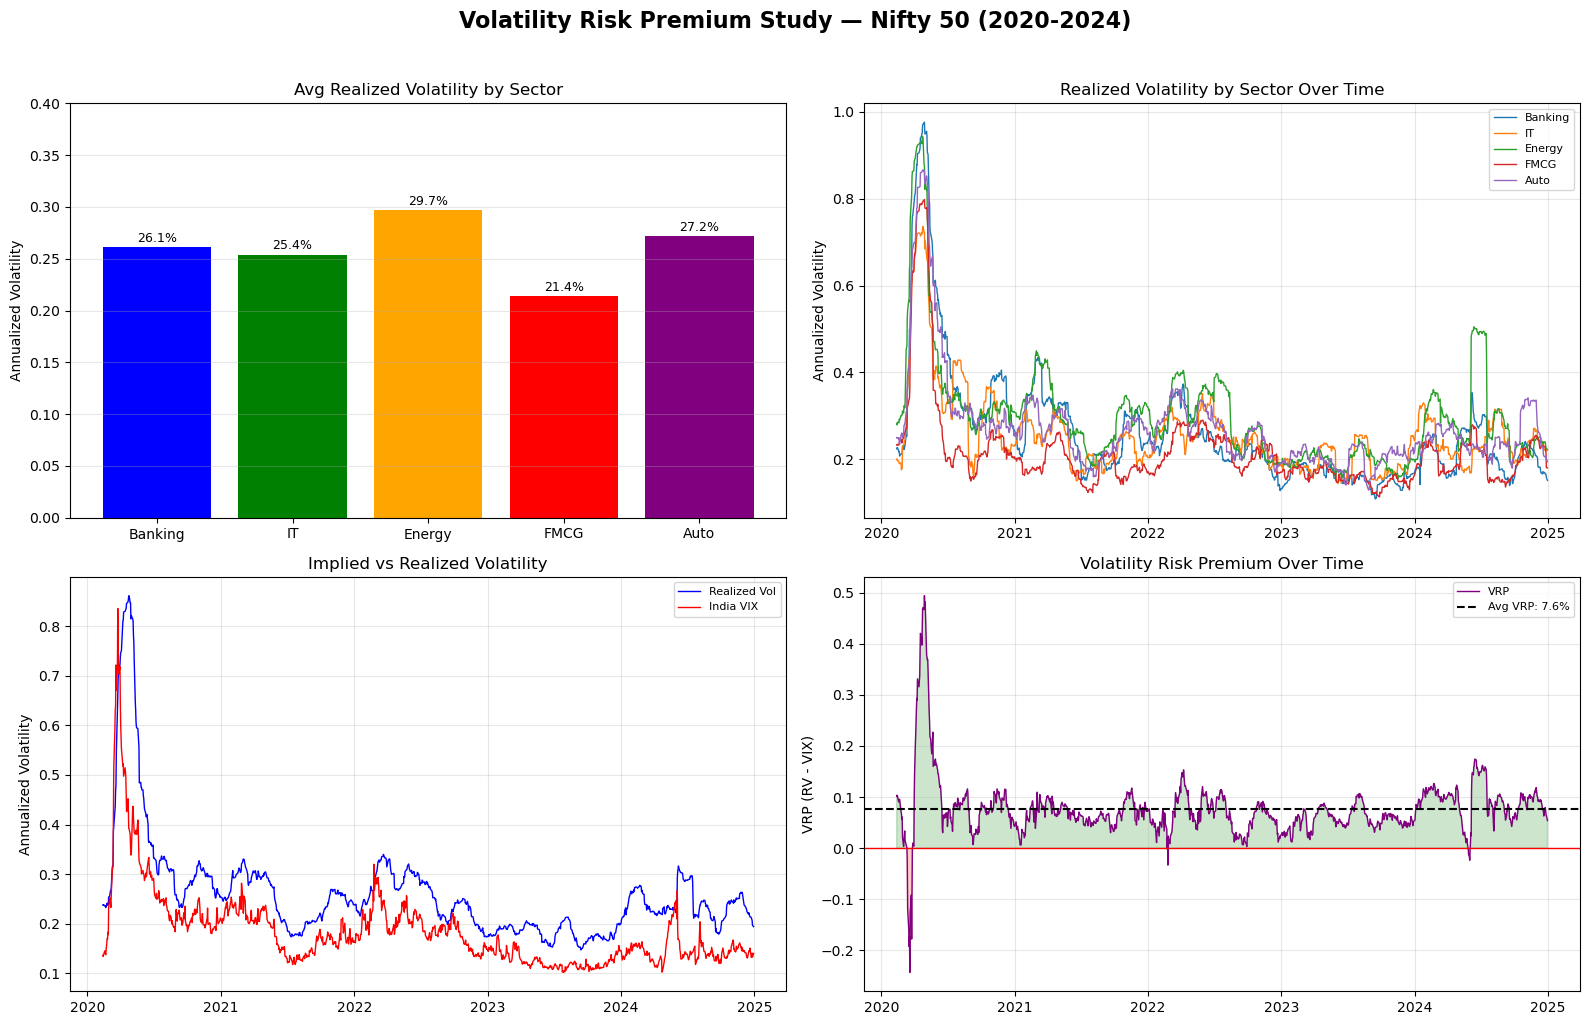

Dashboard saved as vrp_dashboard.png


In [17]:
# Final Dashboard — All findings in one figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Volatility Risk Premium Study — Nifty 50 (2020-2024)", 
             fontsize=16, fontweight="bold", y=1.02)

# Chart 1 — Sector Realized Volatility (bar chart)
sector_names = list(sectors.keys())
sector_vols = [all_rv[stocks].mean(axis=1).mean() for sector, stocks in sectors.items()]
colors = ["blue", "green", "orange", "red", "purple"]
bars = axes[0,0].bar(sector_names, sector_vols, color=colors)
axes[0,0].set_title("Avg Realized Volatility by Sector")
axes[0,0].set_ylabel("Annualized Volatility")
axes[0,0].set_ylim(0, 0.40)
for bar, vol in zip(bars, sector_vols):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f"{vol:.1%}", ha="center", fontsize=9)
axes[0,0].grid(True, alpha=0.3, axis="y")

# Chart 2 — Sector RV over time
for sector, stocks in sectors.items():
    sector_rv = all_rv[stocks].mean(axis=1)
    axes[0,1].plot(sector_rv.index, sector_rv, linewidth=1, label=sector)
axes[0,1].set_title("Realized Volatility by Sector Over Time")
axes[0,1].set_ylabel("Annualized Volatility")
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# Chart 3 — IV vs RV
axes[1,0].plot(avg_rv_aligned.index, avg_rv_aligned, color="blue", linewidth=1, label="Realized Vol")
axes[1,0].plot(vix_aligned.index, vix_aligned, color="red", linewidth=1, label="India VIX")
axes[1,0].set_title("Implied vs Realized Volatility")
axes[1,0].set_ylabel("Annualized Volatility")
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Chart 4 — VRP over time
axes[1,1].plot(vrp.index, vrp, color="purple", linewidth=1, label="VRP")
axes[1,1].axhline(y=vrp.mean(), color="black", linewidth=1.5, linestyle="--", 
                   label=f"Avg VRP: {vrp.mean():.1%}")
axes[1,1].axhline(y=0, color="red", linewidth=1)
axes[1,1].fill_between(vrp.index, vrp, 0, where=(vrp > 0), alpha=0.2, color="green")
axes[1,1].fill_between(vrp.index, vrp, 0, where=(vrp < 0), alpha=0.2, color="red")
axes[1,1].set_title("Volatility Risk Premium Over Time")
axes[1,1].set_ylabel("VRP (RV - VIX)")
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vrp_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("Dashboard saved as vrp_dashboard.png")